DARK STORE OPERATIONS SIMULATOR

Operations Analytics

Objective:
- Identify operational inefficiencies
- Analyze stockouts and cancellations
- Measure service quality
- Quantify business impact
- Generate actionable recommendations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

orders = pd.read_csv("../data/orders.csv")
inventory = pd.read_csv("../data/inventory.csv")

In [16]:
total_revenue = orders[
    "revenue_inr"
].sum()

lost_revenue = orders[
    (orders["stockout_flag"]==1) &
    (orders["cancelled_flag"]==1)
]["revenue_inr"].sum()

revenue_loss_pct = (
    lost_revenue /
    total_revenue
)*100

print(
    "Revenue Loss %:",
    round(revenue_loss_pct,2)
)

Revenue Loss %: 6.08


In [17]:
orders.groupby("stockout_flag").agg({

    "order_id":"count",
    "revenue_inr":"sum",
    "customer_rating":"mean"

}).round(2)

,order_id,revenue_inr,customer_rating
stockout_flag,,,
0,21208,20475627.95,3.89
1,3792,3686577.25,3.86


In [18]:
category_risk = orders.groupby("category").agg({

    "stockout_flag":"mean",
    "cancelled_flag":"mean",
    "revenue_inr":"sum"

}).round(3)

category_risk

,stockout_flag,cancelled_flag,revenue_inr
category,,,
Beverages,0.145,0.057,3371018.89
Dairy,0.151,0.062,3424197.11
Frozen,0.154,0.057,3440934.58
Fruits & Veg,0.154,0.057,3449080.26
Personal Care,0.157,0.067,3487715.83
Snacks,0.151,0.063,3458911.08
Staples,0.151,0.063,3530347.45


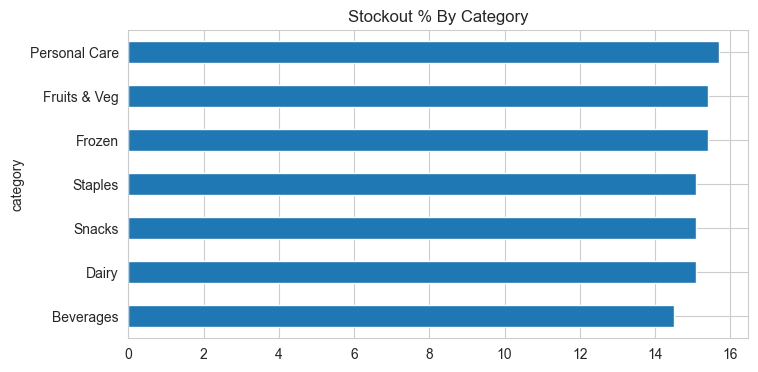

In [19]:
(category_risk["stockout_flag"]*100).sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Stockout % By Category")

plt.show()

In [30]:
inventory_stockout = orders.groupby(
    ["store_id","category"]
)["stockout_flag"] \
.mean() \
.reset_index()

inventory_stockout = inventory_stockout.merge(

    inventory,

    on=[
        "store_id",
        "category"
    ],

    how="left"

)

inventory_stockout.head()

,store_id,category,stockout_flag,max_capacity,current_stock,reorder_point,turnover_rate,below_reorder
0,DS_Bangalore_Koramangala,Beverages,0.137168,1377,1332,344,6.6,0
1,DS_Bangalore_Koramangala,Dairy,0.153846,1816,1120,454,4.3,0
2,DS_Bangalore_Koramangala,Frozen,0.144208,813,723,203,4.4,0
3,DS_Bangalore_Koramangala,Fruits & Veg,0.135556,785,330,196,9.7,0
4,DS_Bangalore_Koramangala,Personal Care,0.160600,949,235,237,7.6,1


In [31]:
inventory.head()

,store_id,category,max_capacity,current_stock,reorder_point,turnover_rate,below_reorder
0,DS_Mumbai_Andheri,Dairy,1419,1347,354,5.5,0
1,DS_Mumbai_Andheri,Fruits & Veg,2280,254,570,9.8,1
2,DS_Mumbai_Andheri,Snacks,826,796,206,6.8,0
3,DS_Mumbai_Andheri,Beverages,1069,265,267,4.9,1
4,DS_Mumbai_Andheri,Personal Care,2063,895,515,3.9,0


In [32]:
inventory.groupby("store_id")["below_reorder"].sum() \
.sort_values(ascending=False)

store_id
DS_Bangalore_Koramangala    2
DS_Delhi_Lajpat             2
DS_Mumbai_Andheri           2
DS_Pune_Kothrud             2
DS_Bangalore_Whitefield     1
DS_Hyderabad_Hitech         1
DS_Mumbai_BKC               1
DS_Delhi_CP                 0
Name: below_reorder, dtype: int64

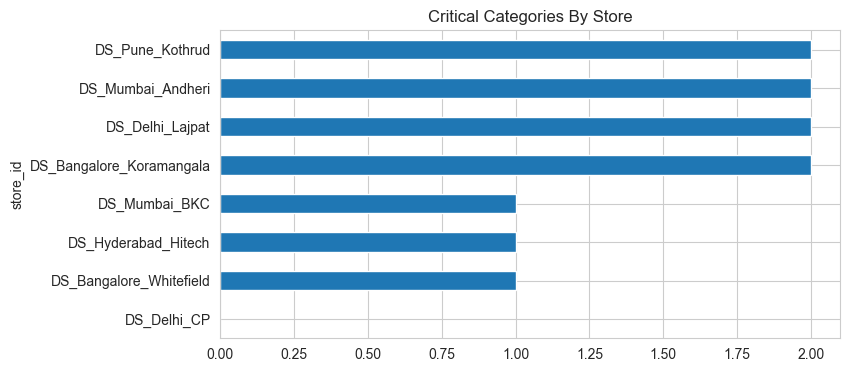

In [33]:
inventory.groupby("store_id")["below_reorder"].sum() \
.sort_values() \
.plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Critical Categories By Store")

plt.show()

In [41]:
peak_analysis = orders.groupby(
    "is_peak_hour"
).agg({

    "order_id":"count",

    "total_fulfillment_time_min":"mean",

    "sla_breached":"mean",

    "stockout_flag":"mean"

}).round(2)

peak_analysis

,order_id,total_fulfillment_time_min,sla_breached,stockout_flag
is_peak_hour,,,,
0,15322,28.94,0.42,0.12
1,9678,39.05,0.95,0.20


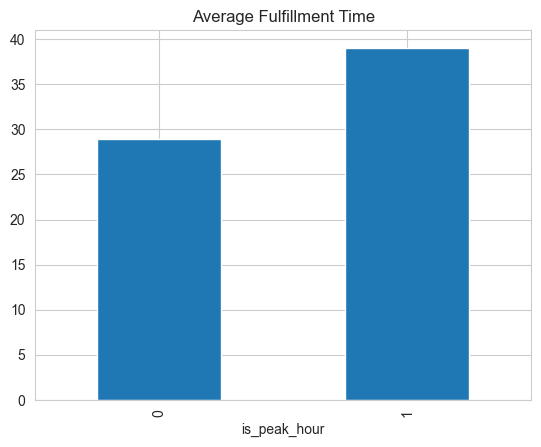

In [48]:
orders.groupby("is_peak_hour")[
    "total_fulfillment_time_min"
].mean().plot(
    kind="bar"
)

plt.title("Average Fulfillment Time")

plt.show()

In [54]:
customer_impact = orders.groupby(
    "sla_breached"
).agg({

    "customer_rating":"mean",

    "revenue_inr":"mean"

}).round(2)

customer_impact

,customer_rating,revenue_inr
sla_breached,,
0,4.19,970.65
1,3.71,964.02


In [55]:
worst_stores = orders.groupby(
    "store_id"
).agg({

    "sla_breached":"mean",
    "stockout_flag":"mean",
    "cancelled_flag":"mean"

})

worst_stores.round(3)

,sla_breached,stockout_flag,cancelled_flag
store_id,,,
DS_Bangalore_Koramangala,0.629,0.144,0.055
DS_Bangalore_Whitefield,0.622,0.154,0.063
DS_Delhi_CP,0.629,0.153,0.057
DS_Delhi_Lajpat,0.627,0.154,0.060
DS_Hyderabad_Hitech,0.624,0.144,0.057
DS_Mumbai_Andheri,0.634,0.155,0.063
DS_Mumbai_BKC,0.630,0.152,0.065
DS_Pune_Kothrud,0.631,0.158,0.066


In [59]:
store_scorecard = orders.groupby(
    "store_id"
).agg({

    "order_id":"count",

    "revenue_inr":"sum",

    "sla_breached":"mean",

    "stockout_flag":"mean",

    "cancelled_flag":"mean",

    "customer_rating":"mean"

}).round(2)

store_scorecard

,order_id,revenue_inr,sla_breached,stockout_flag,cancelled_flag,customer_rating
store_id,,,,,,
DS_Bangalore_Koramangala,3129,3028913.87,0.63,0.14,0.05,3.90
DS_Bangalore_Whitefield,3049,2932356.88,0.62,0.15,0.06,3.89
DS_Delhi_CP,3124,3003380.40,0.63,0.15,0.06,3.88
DS_Delhi_Lajpat,3136,3017359.06,0.63,0.15,0.06,3.89
DS_Hyderabad_Hitech,3107,3011095.69,0.62,0.14,0.06,3.89
DS_Mumbai_Andheri,3112,3072395.19,0.63,0.15,0.06,3.88
DS_Mumbai_BKC,3100,2999789.83,0.63,0.15,0.07,3.88
DS_Pune_Kothrud,3243,3096914.28,0.63,0.16,0.07,3.88


In [60]:
worst_stores["risk_score"] = (

    worst_stores["sla_breached"]*50 +

    worst_stores["stockout_flag"]*30 +

    worst_stores["cancelled_flag"]*20

)

worst_stores.sort_values(
    "risk_score",
    ascending=False
)

,sla_breached,stockout_flag,cancelled_flag,risk_score
store_id,,,,
DS_Pune_Kothrud,0.630897,0.158187,0.066297,37.616405
DS_Mumbai_Andheri,0.634319,0.154563,0.062661,37.606041
DS_Mumbai_BKC,0.630000,0.151935,0.065161,37.361290
DS_Delhi_CP,0.628681,0.152689,0.056658,37.147887
DS_Delhi_Lajpat,0.626594,0.153699,0.059949,37.139668
DS_Bangalore_Whitefield,0.621515,0.154477,0.063299,36.976058
DS_Bangalore_Koramangala,0.628955,0.143816,0.054970,36.861617
DS_Hyderabad_Hitech,0.623753,0.143869,0.056968,36.643064


In [61]:
orders.groupby("store_id").agg({

    "revenue_inr":"sum",
    "customer_rating":"mean"

}).sort_values(
    "revenue_inr",
    ascending=False
).head()

,revenue_inr,customer_rating
store_id,,
DS_Pune_Kothrud,3096914.28,3.883750
DS_Mumbai_Andheri,3072395.19,3.884769
DS_Bangalore_Koramangala,3028913.87,3.898434
DS_Delhi_Lajpat,3017359.06,3.891964
DS_Hyderabad_Hitech,3011095.69,3.893177


In [63]:
sla_pct = round(
    orders["sla_breached"].mean()*100,
    1
)

stockout_pct = round(
    orders["stockout_flag"].mean()*100,
    1
)

cancel_pct = round(
    orders["cancelled_flag"].mean()*100,
    1
)

print("SLA Breach %:", sla_pct)

print("Stockout %:", stockout_pct)

print("Cancellation %:", cancel_pct)

if sla_pct > 20:
    print(
        "Recommendation: Increase peak-hour staffing"
    )

if stockout_pct > 10:
    print(
        "Recommendation: Improve replenishment planning"
    )

if cancel_pct > 5:
    print(
        "Recommendation: Reduce stockout-driven cancellations"
    )

SLA Breach %: 62.8
Stockout %: 15.2
Cancellation %: 6.1
Recommendation: Increase peak-hour staffing
Recommendation: Improve replenishment planning
Recommendation: Reduce stockout-driven cancellations


In [64]:
print("""

OPERATIONS ANALYTICS SUMMARY

1. Quantified revenue loss from stockouts.

2. Identified highest-risk categories.

3. Identified stores with inventory pressure.

4. Measured peak-hour operational stress.

5. Built store-level risk score.

6. Linked inventory shortages to stockouts.

7. Quantified customer impact of SLA failures.

8. Generated data-driven operational recommendations.

""")



OPERATIONS ANALYTICS SUMMARY

1. Quantified revenue loss from stockouts.

2. Identified highest-risk categories.

3. Identified stores with inventory pressure.

4. Measured peak-hour operational stress.

5. Built store-level risk score.

6. Linked inventory shortages to stockouts.

7. Quantified customer impact of SLA failures.

8. Generated data-driven operational recommendations.


